# Classificação semântica pela fração da tela — subj01

Próximo passo do benchmark: treinar com **subconjuntos controlados** do treino, escolhendo número de
imagens únicas, repetições por imagem e, opcionalmente, um **subconjunto semântico**. Este notebook
explora o último eixo: como dar a cada imagem do NSD um rótulo semântico confiável.

A ideia vem do `process_data_ROI.ipynb`: rotular Pessoa / Animal / Outro só quando a categoria ocupa
uma fração mínima da imagem (pessoa ≥ 5%, animal ≥ 2%), para não contar presença incidental, e
setorizar as imagens por faixa de fração para calibrar esses limiares. Aqui a ideia é a mesma, com
duas mudanças:

1. **A fração é medida na tela.** O NSD não mostra a imagem COCO inteira: corta um quadrado
   (`cropBox`) e exibe em 425 × 425 pixels. As máscaras de cada objeto são rasterizadas dentro desse
   recorte, e a fração é a da **união** das máscaras. A soma do campo `area` do COCO sobre a imagem
   inteira, como no notebook original, conta objetos que ficaram fora do recorte e conta duas vezes
   objetos sobrepostos.
2. **O pool é o do benchmark.** Treino: as imagens das sessões de treino do subj01 (tars do
   webdataset, as mesmas do `train_ridgeonly.py` e do `run_frr.py`). Teste: as 1.000 imagens
   compartilhadas, fixas. O subconjunto semântico se aplica **só ao treino**; no teste, o rótulo serve
   para quebrar as métricas por classe.

Nada aqui altera dados do benchmark. O notebook baixa o `nsd_stim_info_merged.csv` e as anotações
COCO 2017 (~250 MB) se faltarem e grava uma tabela de frações em `$MINDEYE_DATA/semantica/`.

## 0. Configuração

In [1]:
import ast
import io
import json
import sys
import urllib.request
import zipfile
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image as IPImage, display
from PIL import Image, ImageDraw

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "mindeye_ridge").is_dir())
sys.path.insert(0, str(REPO / "src"))
from mindeye_ridge import nsd_data
from mindeye_ridge.paths import DATA

SUBJ = 1
NUM_SESSOES = 40                        # pool de treino: as primeiras N sessoes (como --num_sessions)
LADO_TELA = 425                         # o estimulo do NSD tem 425 x 425 pixels na tela
FAIXAS = (0, 2, 5, 10, 20, 40, 100)     # setores de % da tela, [lo, hi)
SEMENTE = 0

SEM = DATA / "semantica"
STIM_INFO = SEM / "nsd_stim_info_merged.csv"
ANOTACOES = [SEM / "annotations" / f"instances_{s}2017.json" for s in ("train", "val")]
CACHE = SEM / f"subj0{SUBJ}_fracao_tela.csv"
IMAGENS = DATA / "coco_images_224_float16.hdf5"   # as 73k imagens ja recortadas, como foram mostradas

URL_STIM = "https://natural-scenes-dataset.s3.amazonaws.com/nsddata/experiments/nsd/nsd_stim_info_merged.csv"
URL_COCO = "http://images.cocodataset.org/annotations/annotations_trainval2017.zip"

plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
COR_TREINO, COR_TESTE = "#2A9D8F", "#E76F51"
print("python:", sys.executable)
print("repo:", REPO, "| dados:", DATA)

python: /home/al.pedro.alberti/envs/fmri/bin/python
repo: /home/al.pedro.alberti/benchmark-modelos | dados: /home/al.pedro.alberti/mindeyev2


In [2]:
def baixa_se_faltar():
    """nsd_stim_info_merged.csv (bucket publico do NSD) e instances_*2017.json do COCO."""
    SEM.mkdir(parents=True, exist_ok=True)
    if not STIM_INFO.exists():
        print("baixando", URL_STIM)
        urllib.request.urlretrieve(URL_STIM, STIM_INFO)
    if not all(a.exists() for a in ANOTACOES):
        zip_path = SEM / "annotations_trainval2017.zip"
        if not zip_path.exists():
            print("baixando", URL_COCO, "(~250 MB)")
            urllib.request.urlretrieve(URL_COCO, zip_path)
        with zipfile.ZipFile(zip_path) as z:
            for a in ANOTACOES:
                z.extract(f"annotations/{a.name}", SEM)
    print("ok:", STIM_INFO.name, *[a.name for a in ANOTACOES])

baixa_se_faltar()

ok: nsd_stim_info_merged.csv instances_train2017.json instances_val2017.json


## 1. O pool do subj01

`nsd_stim_info_merged.csv` liga o índice NSD (0 a 72.999, o mesmo da coluna 0 do `behav` e da linha
em `coco_images_224_float16.hdf5`) ao `cocoId`, ao split COCO de onde a imagem veio e ao recorte
`cropBox = (topo, base, esquerda, direita)`, em frações da imagem COCO cortadas fora.

In [3]:
stim = pd.read_csv(STIM_INFO).set_index("nsdId").drop(columns="Unnamed: 0")

todas = nsd_data.exibicoes_treino(DATA, SUBJ, 40)       # todas as sessoes; NUM_SESSOES recorta depois
ids_teste, _ = nsd_data.exibicoes_teste(DATA, SUBJ)
no_pool = todas["sessao"] < NUM_SESSOES
ids_treino = np.unique(todas["imagem"][no_pool])

assert not set(ids_treino) & set(ids_teste), "imagem de teste no treino"
assert set(ids_teste) == set(stim.index[stim.shared1000]), "teste != shared1000"
print(f"treino ({NUM_SESSOES} sessoes): {no_pool.sum():,} exibicoes, {len(ids_treino):,} imagens unicas")
print(f"teste: {len(ids_teste):,} imagens (shared1000)")
print("split COCO de origem:", stim.loc[np.r_[ids_treino, ids_teste], "cocoSplit"].value_counts().to_dict())

treino (40 sessoes): 27,000 exibicoes, 9,000 imagens unicas
teste: 1,000 imagens (shared1000)
split COCO de origem: {'train2017': 9646, 'val2017': 354}


Imagens únicas e repetições não são independentes das sessões: cada imagem aparece 3 vezes ao longo
das 40 sessões, espaçadas. Com as primeiras N sessões, parte das imagens ainda tem 1 ou 2
repetições. É isso que o pipeline controlado vai ter que desembaraçar.

In [4]:
linhas = []
for n in (1, 2, 5, 10, 15, 20, 30, 40):
    vistas = pd.Series(todas["imagem"][todas["sessao"] < n]).value_counts()
    reps = vistas.value_counts()
    linhas.append({"sessoes": n, "exibicoes": int(vistas.sum()), "imagens_unicas": len(vistas),
                   **{f"com_{r}_rep": int(reps.get(r, 0)) for r in (1, 2, 3)}})
reps_por_sessao = pd.DataFrame(linhas).set_index("sessoes")
reps_por_sessao

,exibicoes,imagens_unicas,com_1_rep,com_2_rep,com_3_rep
sessoes,,,,,
1,688,536,413,94,29
2,1358,981,688,209,84
5,3410,2267,1406,579,282
10,6803,4073,2102,1212,759
15,10158,5552,2332,1834,1386
20,13509,6708,2194,2227,2287
30,20312,8302,1222,2150,4930
40,27000,9000,0,0,9000


Com 40 sessões, as 9.000 imagens de treino têm 3 repetições cada. Com 20, são 6.708 imagens
divididas quase em terços entre 1, 2 e 3 repetições. Recortar por sessão mistura os dois eixos;
para variar um deles com o outro fixo (3.000 imagens × 1 repetição contra 1.000 × 3, mesmo número
de exibições), o pipeline controlado tem de sortear **exibições** dentro das 40 sessões.

## 2. Fração da tela de cada categoria

Para cada imagem do pool, cada anotação COCO (polígono, ou RLE nas anotações `iscrowd`) é desenhada
numa tela de 425 × 425 que corresponde ao recorte mostrado. Por imagem, a tabela guarda:

- `cat_<nome>`: % da tela coberta pela união das máscaras de cada uma das 80 categorias;
- `sup_<nome>`: o mesmo para as 12 supercategorias (união das categorias dela);
- `anotada`: % da tela coberta por qualquer objeto (o resto é fundo: céu, chão, parede, que o
  `instances` do COCO não anota);
- `areacoco_<sup>`: a medida do `process_data_ROI` (soma de `area` sobre a imagem COCO inteira), para
  comparar.

Tudo em % (0 a 100). O resultado fica em cache no CSV.

In [5]:
def carrega_coco(caminhos):
    cats, tamanhos, anots = {}, {}, {}
    for c in caminhos:
        with open(c) as f:
            d = json.load(f)
        cats.update({k["id"]: (k["name"], k["supercategory"]) for k in d["categories"]})
        tamanhos.update({im["id"]: (im["width"], im["height"]) for im in d["images"]})
        for a in d["annotations"]:
            anots.setdefault(a["image_id"], []).append(a)
    return cats, tamanhos, anots


def rle_para_mascara(seg):
    """RLE nao comprimido do COCO (anotacoes iscrowd), que percorre a imagem por colunas."""
    h, w = seg["size"]
    plano = np.zeros(h * w, dtype=np.uint8)
    pos, val = 0, 0
    for c in seg["counts"]:
        plano[pos:pos + c] = val
        pos, val = pos + c, val ^ 1
    return plano.reshape(w, h).T


def mascaras_na_tela(nsd_id, lado=LADO_TELA):
    """{categoria: mascara booleana lado x lado} no recorte que o NSD mostrou."""
    coco_id = int(stim.at[nsd_id, "cocoId"])
    topo, base, esq, dir_ = ast.literal_eval(stim.at[nsd_id, "cropBox"])
    W, H = tamanhos[coco_id]
    x0, y0 = esq * W, topo * H
    largura = W * (1 - esq - dir_)                 # o recorte e quadrado
    escala = lado / largura
    telas = {}
    for a in anots.get(coco_id, []):
        nome = cats[a["category_id"]][0]
        tela = telas.setdefault(nome, Image.new("L", (lado, lado), 0))
        seg = a["segmentation"]
        if isinstance(seg, list):
            d = ImageDraw.Draw(tela)
            for p in seg:
                if len(p) >= 6:
                    d.polygon([((x - x0) * escala, (y - y0) * escala) for x, y in zip(p[0::2], p[1::2])], fill=1)
        else:
            m = rle_para_mascara(seg)[round(y0):round(y0 + largura), round(x0):round(x0 + largura)]
            tela.paste(1, mask=Image.fromarray(m * 255).resize((lado, lado), Image.NEAREST))
    return {n: np.asarray(t, dtype=bool) for n, t in telas.items()}


cats, tamanhos, anots = carrega_coco(ANOTACOES)
CAT_SUP = dict(cats.values())                              # categoria -> supercategoria
SUPERCATS = sorted(set(CAT_SUP.values()))
print(f"{len(CAT_SUP)} categorias em {len(SUPERCATS)} supercategorias:", ", ".join(SUPERCATS))

80 categorias em 12 supercategorias: accessory, animal, appliance, electronic, food, furniture, indoor, kitchen, outdoor, person, sports, vehicle


In [6]:
def tabela_fracoes(ids):
    linhas = []
    for nid in ids:
        coco_id = int(stim.at[nid, "cocoId"])
        W, H = tamanhos[coco_id]
        masc = mascaras_na_tela(nid)
        lin = {"nsd_id": nid, "coco_id": coco_id, "n_objetos": len(anots.get(coco_id, []))}
        por_sup, tudo = {}, np.zeros((LADO_TELA, LADO_TELA), bool)
        for nome, m in masc.items():
            lin[f"cat_{nome}"] = 100 * m.mean()
            s = CAT_SUP[nome]
            por_sup[s] = por_sup[s] | m if s in por_sup else m
            tudo |= m
        lin.update({f"sup_{s}": 100 * m.mean() for s, m in por_sup.items()})
        lin["anotada"] = 100 * tudo.mean()
        for a in anots.get(coco_id, []):
            k = f"areacoco_{cats[a['category_id']][1]}"
            lin[k] = lin.get(k, 0) + 100 * a["area"] / (W * H)
        linhas.append(lin)
    colunas = (["coco_id", "n_objetos", "anotada"] + [f"sup_{s}" for s in SUPERCATS]
               + [f"cat_{c}" for c in CAT_SUP] + [f"areacoco_{s}" for s in SUPERCATS])
    return pd.DataFrame(linhas).set_index("nsd_id").reindex(columns=colunas).fillna(0)


pool = np.r_[ids_treino, ids_teste]
if CACHE.exists():
    fr = pd.read_csv(CACHE, index_col="nsd_id")
    faltam = np.setdiff1d(pool, fr.index)
    if len(faltam):
        fr = pd.concat([fr, tabela_fracoes(faltam)])
else:
    fr = tabela_fracoes(np.union1d(np.unique(todas["imagem"]), ids_teste))   # as 40 sessoes, para o cache servir a qualquer N
fr.to_csv(CACHE)
fr["split"] = np.where(fr.index.isin(ids_teste), "teste", "treino")
fr = fr.loc[pool]
sup = fr[[f"sup_{s}" for s in SUPERCATS]].rename(columns=lambda c: c[4:])
print(f"{len(fr):,} imagens | cache: {CACHE}")
print(f"sem nenhuma anotacao na tela: {(fr.anotada == 0).sum()} | "
      f"sem anotacao no COCO: {(fr.n_objetos == 0).sum()}")
fr[["coco_id", "split", "n_objetos", "anotada", *[f"sup_{s}" for s in SUPERCATS]]].head()

10,000 imagens | cache: /home/al.pedro.alberti/mindeyev2/semantica/subj01_fracao_tela.csv
sem nenhuma anotacao na tela: 10 | sem anotacao no COCO: 0


,coco_id,split,n_objetos,anotada,sup_accessory,sup_animal,sup_appliance,sup_electronic,sup_food,sup_furniture,sup_indoor,sup_kitchen,sup_outdoor,sup_person,sup_sports,sup_vehicle
nsd_id,,,,,,,,,,,,,,,,
13,24610,treino,16,16.728028,1.324291,0.000000,0.0,0.342145,0.000000,11.472388,4.913495,0.000000,0.0,0.000000,0.000000,0.0
27,254016,treino,16,26.313080,0.000000,0.000000,0.0,0.000000,19.862699,0.000000,0.000000,2.438754,0.0,4.207059,0.000000,0.0
71,286908,treino,20,80.901315,0.000000,0.000000,0.0,0.000000,0.742422,41.413426,0.000000,61.364706,0.0,0.000000,0.000000,0.0
85,516318,treino,3,3.655640,0.000000,0.182699,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,2.447612,1.030865,0.0
88,464251,treino,3,8.586298,0.000000,3.152388,0.0,0.000000,0.000000,5.433910,0.000000,0.000000,0.0,0.000000,0.000000,0.0


## 3. Conferência: a máscara cai em cima da imagem mostrada?

As imagens de `coco_images_224_float16.hdf5` já são o recorte exibido, reduzido a 224 × 224. Se a
convenção do `cropBox` estiver certa, as máscaras coincidem com os objetos.

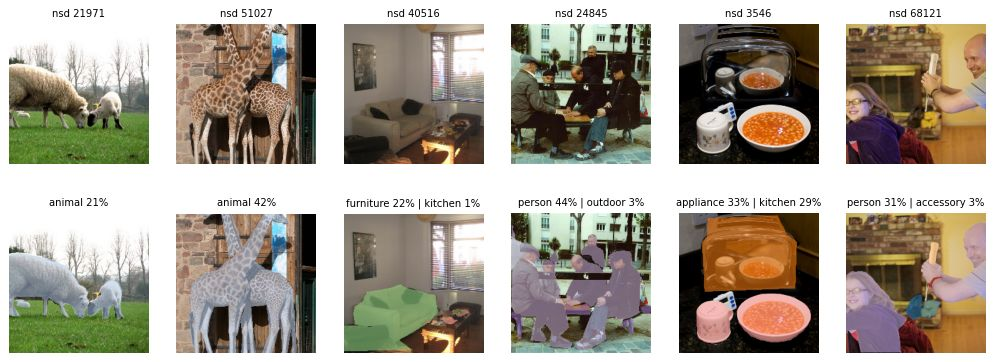

In [7]:
imagens_h5 = h5py.File(IMAGENS, "r")
CORES_SUP = dict(zip(SUPERCATS, plt.cm.tab20(np.linspace(0, 1, 20))[::1][:len(SUPERCATS)]))


def imagem(nsd_id):
    return imagens_h5["images"][nsd_id].astype(np.float32).transpose(1, 2, 0)


def mostra_jpeg(fig, qualidade=80):
    """Galerias de fotos em JPEG: o notebook fica leve no git."""
    buf = io.BytesIO()
    fig.savefig(buf, format="jpeg", pil_kwargs={"quality": qualidade}, bbox_inches="tight")
    plt.close(fig)
    display(IPImage(buf.getvalue()))


def sobreposicao(nsd_id):
    """Imagem com as mascaras de cada supercategoria pintadas por cima."""
    img = imagem(nsd_id)
    cor = np.zeros((224, 224, 3)); alfa = np.zeros((224, 224, 1))
    for nome, m in mascaras_na_tela(nsd_id).items():
        m224 = np.asarray(Image.fromarray(m).resize((224, 224), Image.NEAREST))
        cor[m224] = CORES_SUP[CAT_SUP[nome]][:3]; alfa[m224] = 0.55
    return img * (1 - alfa) + cor * alfa


rng = np.random.default_rng(SEMENTE)
amostra = rng.choice(fr.index[fr.anotada > 20], 6, replace=False)
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for j, nid in enumerate(amostra):
    axes[0, j].imshow(imagem(nid)); axes[1, j].imshow(sobreposicao(nid))
    top = sup.loc[nid].sort_values(ascending=False).head(2)
    axes[0, j].set_title(f"nsd {nid}", fontsize=8)
    axes[1, j].set_title(" | ".join(f"{k} {v:.0f}%" for k, v in top.items() if v > 0), fontsize=8)
for ax in axes.flat:
    ax.axis("off")
mostra_jpeg(fig)

As máscaras coincidem com os objetos, então a convenção `(topo, base, esquerda, direita)` está
certa. Das 10.000 imagens, 10 não têm nenhum objeto anotado dentro do recorte.

## 4. Tela × área COCO

O `process_data_ROI` usa `soma(area) / (largura × altura)` da imagem COCO inteira. A comparação
mostra quanto essa medida se afasta da fração efetivamente vista, e quantas imagens mudam de lado
no limiar de 5% para pessoa.

person   limiar 5%:   33 passam so pela area COCO,  255 so pela tela | area COCO > 100%: 0
animal   limiar 2%:    5 passam so pela area COCO,   58 so pela tela | area COCO > 100%: 1
vehicle  limiar 5%:   26 passam so pela area COCO,   77 so pela tela | area COCO > 100%: 2


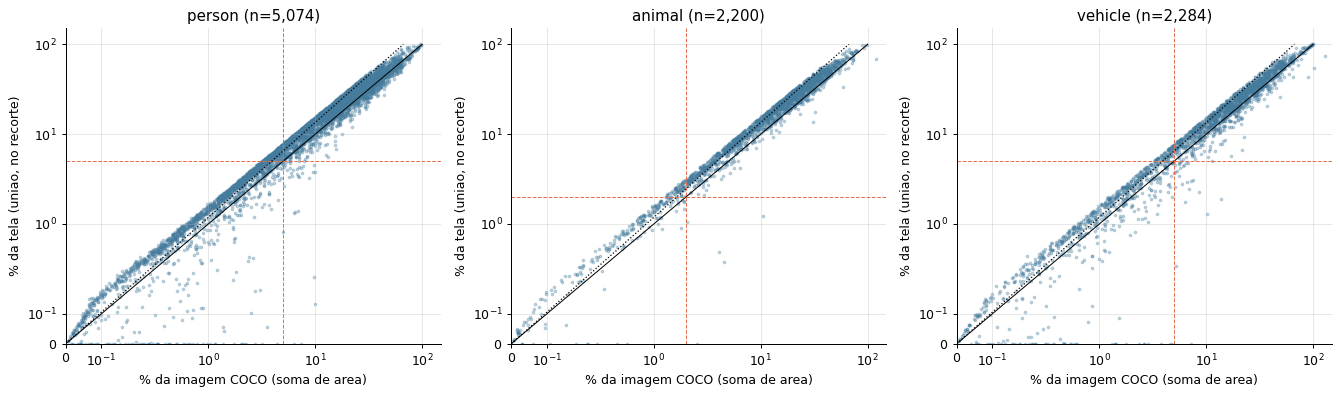

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, s, lim in zip(axes, ("person", "animal", "vehicle"), (5, 2, 5)):
    tem = (fr[f"areacoco_{s}"] > 0) | (fr[f"sup_{s}"] > 0)
    x, y = fr.loc[tem, f"areacoco_{s}"], fr.loc[tem, f"sup_{s}"]
    ax.scatter(x, y, s=4, alpha=0.3, color="#457B9D")
    ax.plot([0, 100], [0, 100], color="k", lw=0.8)
    ax.axvline(lim, color="#E76F51", lw=0.8, ls="--"); ax.axhline(lim, color="#E76F51", lw=0.8, ls="--")
    ax.plot([0, 100 / 1.5], [0, 100], color="k", lw=1, ls=":")
    ax.set_xscale("symlog", linthresh=0.1, linscale=0.3); ax.set_yscale("symlog", linthresh=0.1, linscale=0.3)
    ax.set(xlim=(0, 150), ylim=(0, 150),
           xlabel="% da imagem COCO (soma de area)", ylabel="% da tela (uniao, no recorte)",
           title=f"{s} (n={tem.sum():,})")
    so_coco = ((x >= lim) & (y < lim)).sum(); so_tela = ((x < lim) & (y >= lim)).sum()
    print(f"{s:8s} limiar {lim}%: {so_coco:4d} passam so pela area COCO, {so_tela:4d} so pela tela | "
          f"area COCO > 100%: {(x > 100).sum()}")
plt.tight_layout(); plt.show()

Na tela, o mesmo objeto ocupa uma fração **maior**. O recorte quadrado descarta as bordas do lado
maior (um quarto da imagem COCO, se ela é 4:3; um terço, se é 3:2), então um objeto inteiro dentro
do recorte cresce de 1,33× a 1,5× (linha pontilhada: y = 1,5x; a contínua é y = x). Abaixo dela ficam os
objetos parcialmente cortados; os pontos colados no eixo x ficaram fora da tela. No limiar de 5%,
255 imagens passam a contar como pessoa e 33 deixam de contar.

A regra de prioridade do `process_data_ROI` medida na tela (seção 9) dá 3.436 pessoa, 1.692 animal
e 2.672 outro. O notebook original dava 3.115, 1.606 e 2.668 com a área COCO, no mesmo pool de
10.000 imagens.

## 5. Quanto da tela cada supercategoria ocupa

Presença = qualquer pixel na tela. À esquerda, em quantas imagens do pool cada supercategoria
aparece; à direita, quanto da tela ela ocupa quando aparece.

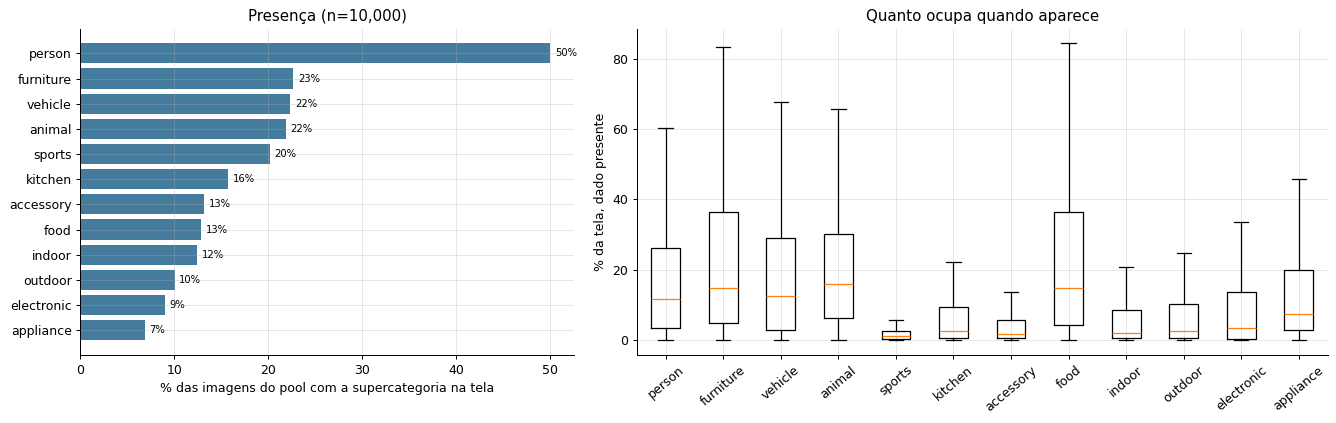

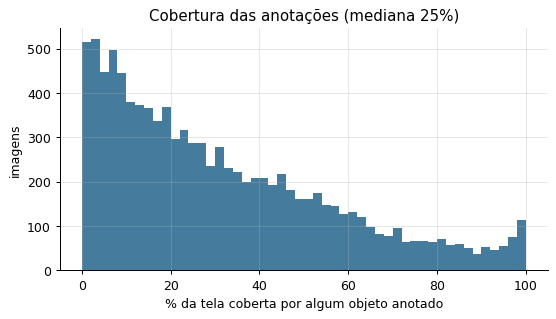

In [9]:
presente = sup > 0
ordem = presente.sum().sort_values(ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), gridspec_kw={"width_ratios": [1, 1.4]})
pct = 100 * presente[ordem].mean()
axes[0].barh(ordem[::-1], pct[::-1], color="#457B9D")
for i, v in enumerate(pct[::-1]):
    axes[0].text(v + 0.5, i, f"{v:.0f}%", va="center", fontsize=8)
axes[0].set(xlabel="% das imagens do pool com a supercategoria na tela", title=f"Presença (n={len(sup):,})")
axes[1].boxplot([sup.loc[presente[s], s] for s in ordem], showfliers=False)
axes[1].set_xticks(range(1, len(ordem) + 1), ordem)
axes[1].set(ylabel="% da tela, dado presente", title="Quanto ocupa quando aparece")
axes[1].tick_params(axis="x", rotation=40)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(fr.anotada, bins=50, color="#457B9D")
ax.set(xlabel="% da tela coberta por algum objeto anotado", ylabel="imagens",
       title=f"Cobertura das anotações (mediana {fr.anotada.median():.0f}%)")
plt.show()

- **person** aparece em metade das imagens, mas em ~940 delas ocupa menos de 2% da tela: é a
  presença incidental que o limiar quer cortar.
- **sports, accessory, kitchen, indoor, outdoor** quase sempre são pequenas (mediana abaixo de 5%):
  objetos que acompanham a cena (raquete, bolsa, garfo, placa), não o assunto dela.
- As candidatas naturais a classe são as que ocupam muito quando aparecem: **person, furniture,
  vehicle, animal, food**.
- A anotação cobre só 25% da tela na mediana. O `instances` do COCO não anota fundo (céu, grama,
  parede), então a fração da tela é sempre a de objetos contáveis, nunca a da cena.

## 6. Setorização por faixa da tela

Cada imagem cai, para cada supercategoria, numa faixa de % da tela (`FAIXAS`). A tabela conta as
imagens por faixa (ausente = nenhum pixel), e as galerias mostram imagens sorteadas em cada faixa
— é o que calibra a partir de quanto uma categoria deixa de ser incidental.

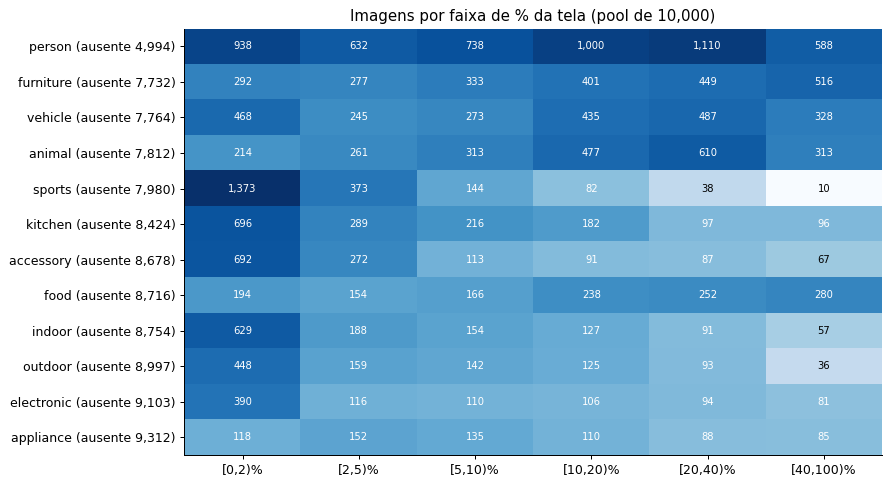

In [10]:
ROTULOS_FAIXA = [f"[{lo},{hi})" for lo, hi in zip(FAIXAS[:-1], FAIXAS[1:])]


def faixa(valores):
    f = pd.cut(valores, bins=list(FAIXAS[:-1]) + [np.inf], right=False, labels=ROTULOS_FAIXA)
    return f.cat.add_categories("ausente").fillna("ausente").where(valores > 0, "ausente")


setores = pd.DataFrame({s: faixa(sup[s]).value_counts() for s in ordem}).T[["ausente", *ROTULOS_FAIXA]]

fig, ax = plt.subplots(figsize=(10, 5.5))
v = setores[ROTULOS_FAIXA].values
ax.imshow(np.log1p(v), cmap="Blues", aspect="auto")
for (i, j), n in np.ndenumerate(v):
    ax.text(j, i, f"{n:,}", ha="center", va="center", fontsize=8,
            color="white" if np.log1p(n) > 0.6 * np.log1p(v.max()) else "black")
ax.set_xticks(range(len(ROTULOS_FAIXA)), [f"{r}%" for r in ROTULOS_FAIXA])
ax.set_yticks(range(len(ordem)), [f"{s} (ausente {setores.at[s, 'ausente']:,})" for s in ordem])
ax.set(title=f"Imagens por faixa de % da tela (pool de {len(sup):,})"); ax.grid(False)
plt.tight_layout(); plt.show()

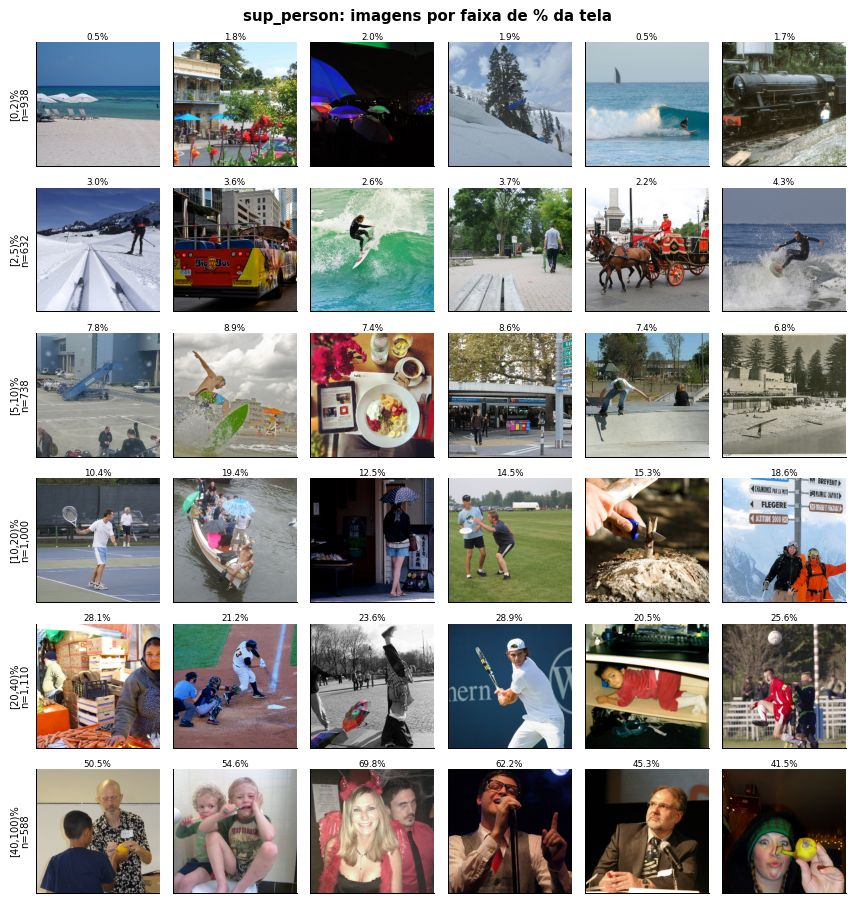

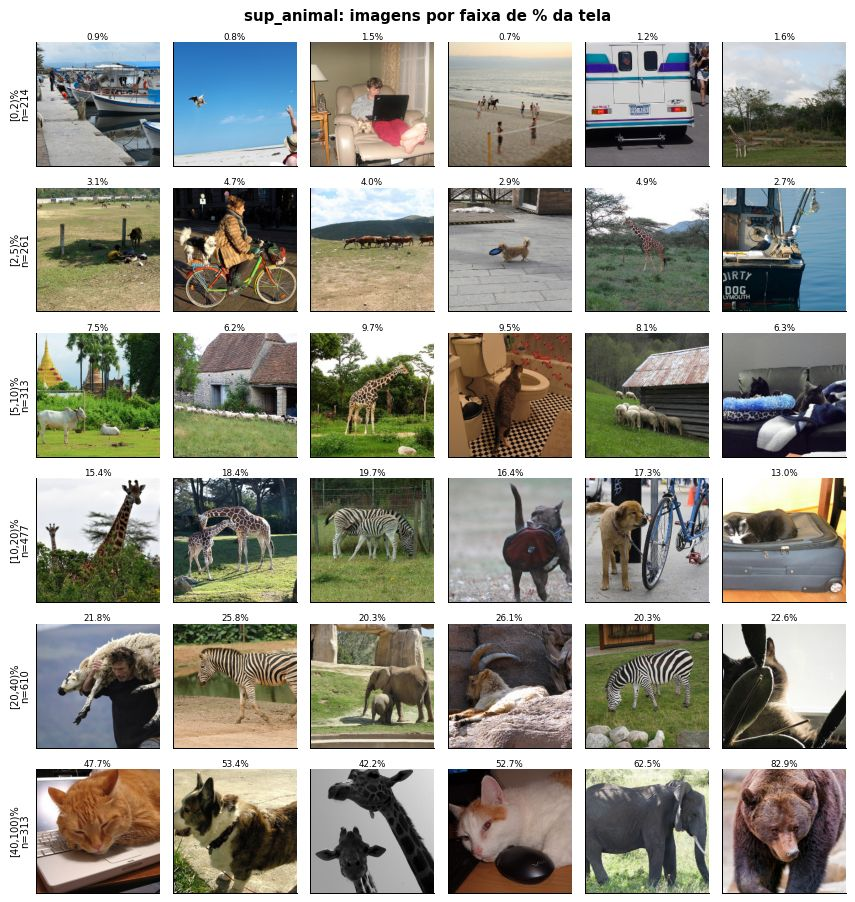

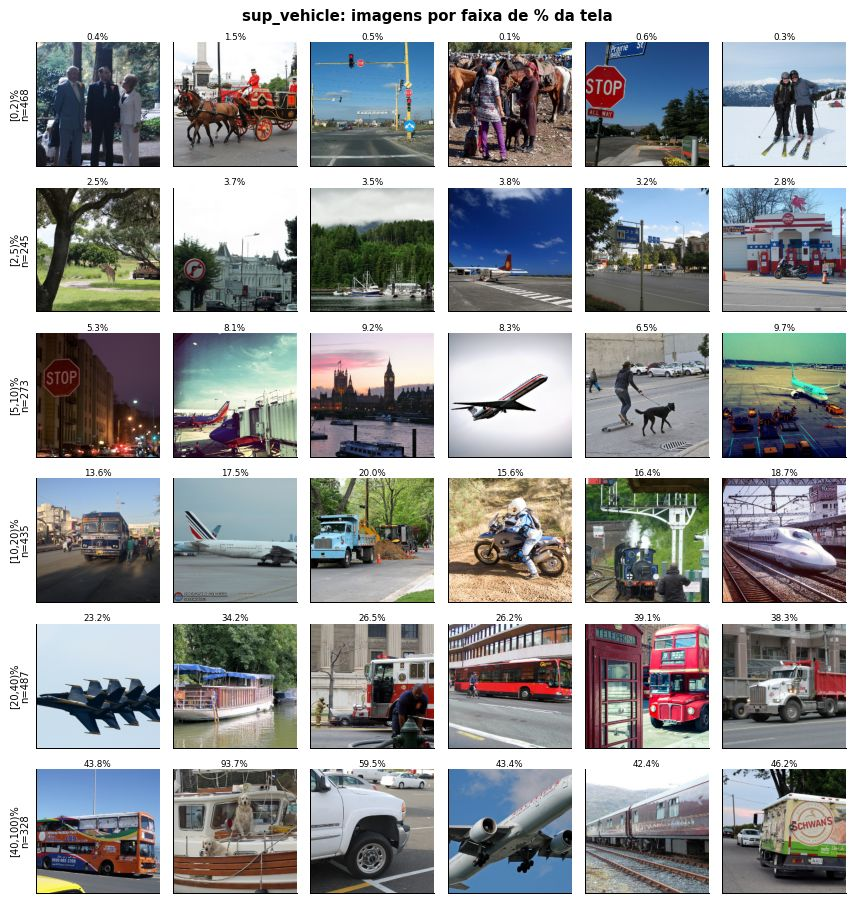

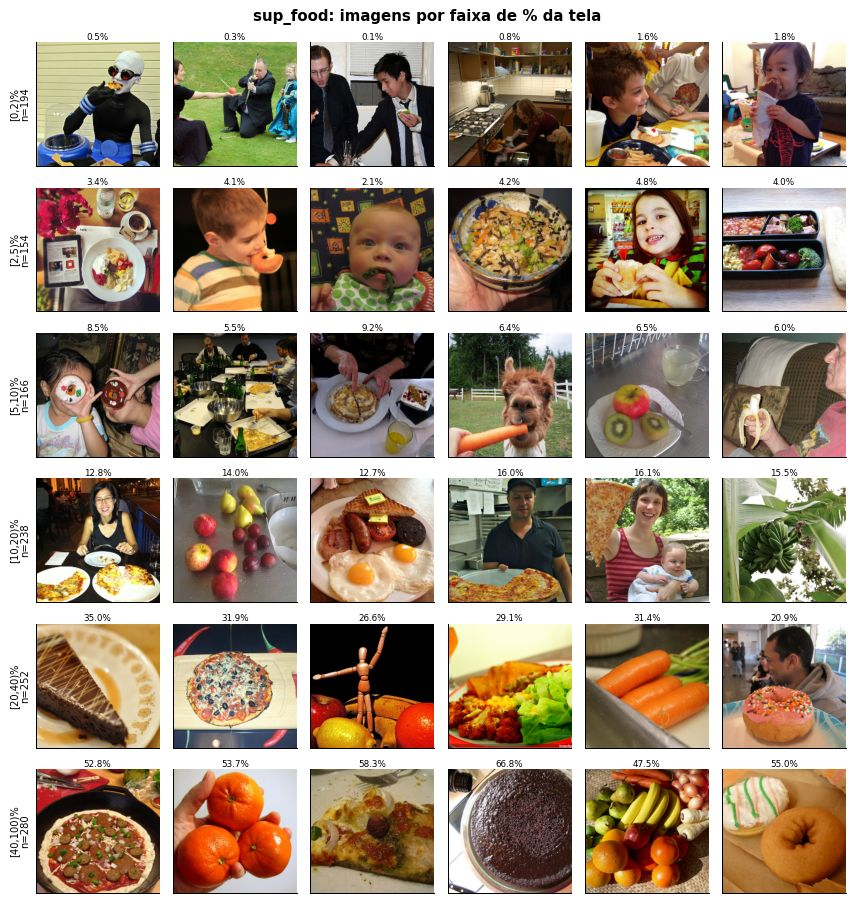

In [11]:
def galeria_por_faixa(coluna, n=6, dados=fr, semente=SEMENTE):
    rng = np.random.default_rng(semente)
    f = faixa(dados[coluna])
    fig, axes = plt.subplots(len(ROTULOS_FAIXA), n, figsize=(1.6 * n, 1.7 * len(ROTULOS_FAIXA)))
    for i, rot in enumerate(ROTULOS_FAIXA):
        ids = dados.index[f == rot]
        escolha = rng.choice(ids, min(n, len(ids)), replace=False) if len(ids) else []
        for j in range(n):
            ax = axes[i, j]; ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
            if j < len(escolha):
                ax.imshow(imagem(escolha[j]))
                ax.set_title(f"{dados.at[escolha[j], coluna]:.1f}%", fontsize=7, pad=2)
            else:
                ax.axis("off")
        axes[i, 0].set_ylabel(f"{rot}%\nn={len(ids):,}", fontsize=8)
    fig.suptitle(f"{coluna}: imagens por faixa de % da tela", fontweight="bold")
    plt.tight_layout()
    mostra_jpeg(fig)


for s in ("person", "animal", "vehicle", "food"):
    galeria_por_faixa(f"sup_{s}")

Nas galerias, abaixo de 2% a categoria é figurante (um animal ao fundo, alguém dentro de um ônibus).
Entre 2% e 10% às vezes já é o assunto, mas pequeno e distante (um rebanho no horizonte, um
surfista). De 10% em diante, quase sempre é o assunto. Comida é o caso mais ambíguo: até ~10%,
quase sempre é alguém comendo.

## 7. Supercategoria dominante

A dominante é a de maior fração da tela. O que interessa para rotular é se ela domina **de fato**:
quanto da tela ocupa e por quanto ganha da segunda.

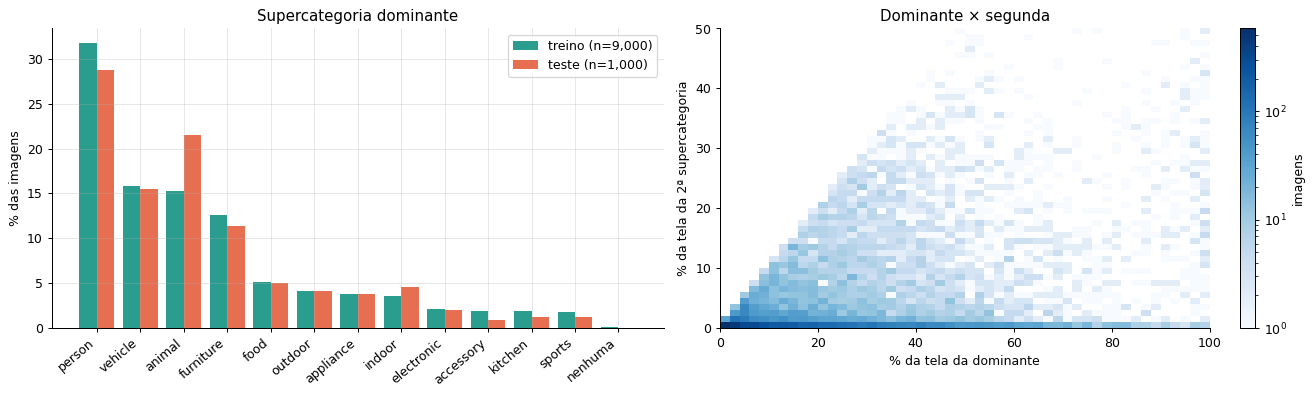

,>= 5% e margem >= 0,>= 10% e margem >= 5,>= 20% e margem >= 10,>= 30% e margem >= 20,>= 50% e margem >= 30
imagens,8485,6763,4740,3112,1379


In [12]:
valores = np.sort(sup.values, axis=1)
dom = sup.idxmax(axis=1).where(sup.max(axis=1) > 0, "nenhuma")
frac_dom, margem = valores[:, -1], valores[:, -1] - valores[:, -2]

cont = pd.crosstab(dom, fr.split).reindex(columns=["treino", "teste"]).sort_values("treino", ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
x = np.arange(len(cont))
for k, (col, cor) in enumerate((("treino", COR_TREINO), ("teste", COR_TESTE))):
    axes[0].bar(x + (k - 0.5) * 0.4, 100 * cont[col] / cont[col].sum(), 0.4, color=cor,
                label=f"{col} (n={cont[col].sum():,})")
axes[0].set_xticks(x, cont.index, rotation=40, ha="right")
axes[0].set(ylabel="% das imagens", title="Supercategoria dominante"); axes[0].legend()
from matplotlib.colors import LogNorm
h = axes[1].hist2d(frac_dom, valores[:, -2], bins=50, range=[[0, 100], [0, 50]], cmap="Blues", norm=LogNorm())
plt.colorbar(h[3], ax=axes[1], label="imagens")
axes[1].set(xlabel="% da tela da dominante", ylabel="% da tela da 2ª supercategoria",
            title="Dominante × segunda"); axes[1].grid(False)
plt.tight_layout(); plt.show()

limiares = pd.DataFrame({f">= {f}% e margem >= {m}": ((frac_dom >= f) & (margem >= m)).sum()
                         for f, m in ((5, 0), (10, 5), (20, 10), (30, 20), (50, 30))}, index=["imagens"])
limiares

O teste não é uma amostra uniforme do treino: tem mais animal (21% contra 15% como dominante). No
gráfico da direita, a linha de baixo (2ª = 0) são as imagens com uma supercategoria só. A
maioria das imagens com dominante grande tem uma segunda pequena, abaixo de 10%.

## 8. Co-ocorrência

Uma classe "pura" exige que as outras estejam ausentes ou pequenas. A matriz mostra, entre as imagens
em que a supercategoria da linha ocupa ≥ 10% da tela, a fração em que a da coluna ocupa ≥ 2%.

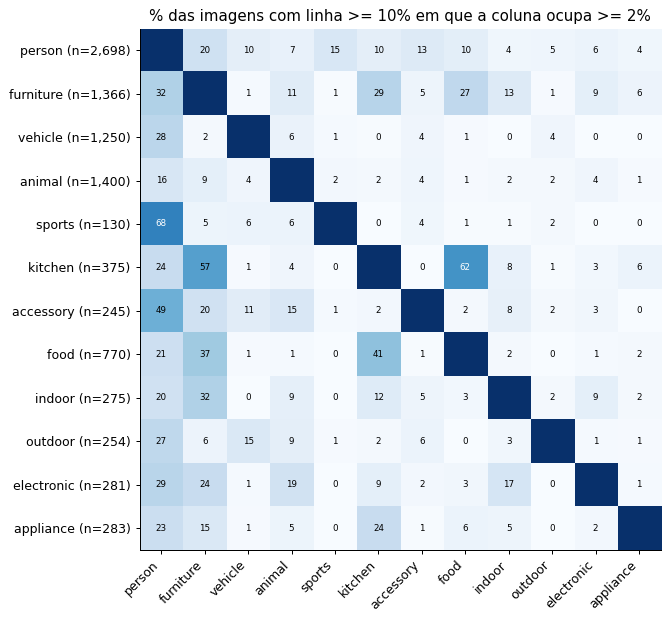

In [13]:
DOMINA, PRESENTE = 10, 2
linhas = {a: (sup.loc[sup[a] >= DOMINA] >= PRESENTE).mean() for a in ordem}
co = pd.DataFrame(linhas).T[ordem]
n_linha = (sup >= DOMINA).sum()

fig, ax = plt.subplots(figsize=(9, 7))
ax.imshow(co.values, cmap="Blues", vmin=0, vmax=1); ax.grid(False)
for (i, j), p in np.ndenumerate(co.values):
    if i != j:
        ax.text(j, i, f"{100 * p:.0f}", ha="center", va="center", fontsize=7, color="white" if p > 0.6 else "black")
ax.set_xticks(range(len(ordem)), ordem, rotation=45, ha="right")
ax.set_yticks(range(len(ordem)), [f"{a} (n={n_linha[a]:,})" for a in ordem])
ax.set(title=f"% das imagens com linha >= {DOMINA}% em que a coluna ocupa >= {PRESENTE}%")
plt.tight_layout(); plt.show()

Duas co-ocorrências pesam numa classe "pura":

- **sports → person** (68%): o equipamento vem com quem o usa. Sports não serve como classe.
- **food → kitchen e furniture** (41% e 37%): prato, garfo e tigela são `kitchen`, e a mesa de
  jantar (`dining table`) é `furniture`. Se móveis for uma classe, comida perde as refeições postas
  na mesa.

## 9. Do rótulo às classes

Duas regras, ambas sobre a fração da tela:

- **Prioridade** (a do `process_data_ROI`): pessoa se ≥ 5%; senão animal se ≥ 2%; senão "outro" se a
  supercategoria dominante entre as restantes estiver em `{vehicle, furniture, outdoor}`; senão
  descartada.
- **Exclusiva**: cada classe é uma lista de colunas da tabela (supercategorias `sup_*` ou
  categorias `cat_*`); a imagem é da classe se ela ocupa ≥ `minimo`% da tela e **todas** as outras
  classes ficam abaixo de `maximo_outros`%. Nenhuma ou mais de uma: descartada. Troca quantidade
  por pureza — uma pessoa montada num cavalo não entra em classe nenhuma. O que não é classe
  (raquete, prato, televisão) não conta contra a pureza.

Numa classe com mais de uma coluna, a fração é a soma delas, limitada a 100 (aproxima a união;
sobreposição entre categorias diferentes é pequena).

In [14]:
def rotulo_prioridade(sup, pessoa_min=5, animal_min=2, outros_validos=("vehicle", "furniture", "outdoor")):
    resto = sup.drop(columns=["person", "animal"])
    dom_resto = resto.idxmax(axis=1).where(resto.max(axis=1) > 0)
    rot = pd.Series(None, index=sup.index, dtype=object)
    rot[dom_resto.isin(outros_validos)] = "outro"
    rot[sup.animal >= animal_min] = "animal"
    rot[sup.person >= pessoa_min] = "pessoa"
    return rot


def fracao_classes(dados, classes):
    return pd.DataFrame({c: dados[list(cols)].sum(axis=1).clip(upper=100) for c, cols in classes.items()})


def rotulo_exclusivo(dados, classes, minimo=10, maximo_outros=2):
    f = fracao_classes(dados, classes)
    rot = pd.Series(None, index=sup.index, dtype=object)
    for c in classes:
        outras = f.drop(columns=c)
        rot[(f[c] >= minimo) & (outras < maximo_outros).all(axis=1)] = c
    return rot


def contagem(rot, nome):
    t = pd.crosstab(rot.fillna("descartada").rename("classe"), fr.split).reindex(columns=["treino", "teste"]).fillna(0).astype(int)
    t.columns = pd.MultiIndex.from_product([[nome], t.columns])
    return t


CLASSES = {"pessoa": ["sup_person"], "animal": ["sup_animal"], "veiculo": ["sup_vehicle"],
           "comida": ["sup_food"], "moveis": ["sup_furniture"]}

rot_prio = rotulo_prioridade(sup)
rot_excl = rotulo_exclusivo(fr, CLASSES, minimo=10, maximo_outros=2)
pd.concat([contagem(rot_prio, "prioridade"), contagem(rot_excl, "exclusiva (10%, <2%)")], axis=1).fillna(0).astype(int)

prioridade       exclusiva (10%, <2%)      
split          treino teste               treino teste
classe                                                
animal           1480   212                  880   130
descartada       1958   242                 5082   557
outro            2397   275                    0     0
pessoa           3165   271                 1484   125
comida              0     0                  336    39
moveis              0     0                  488    62
veiculo             0     0                  730    87

A regra de prioridade aproveita 78% do treino, mas o "outro" junta avião, maçã sobre a mesa e
banheiro (`toilet` é furniture). A exclusiva aproveita 44%, com classes visualmente coerentes (ver
as galerias abaixo). Comida é a menor classe.

Como a classe é uma lista de colunas, dá para trocar móveis inteiro (cadeira, sofá, cama, vaso de
planta, mesa de jantar, vaso sanitário) por móveis de sala e quarto. A mesa de jantar deixa de
competir com a comida:

In [15]:
CLASSES_SALA = {**CLASSES, "moveis": ["cat_couch", "cat_bed", "cat_chair"]}
rot_sala = rotulo_exclusivo(fr, CLASSES_SALA, minimo=10, maximo_outros=2)
pd.concat([contagem(rot_excl, "moveis = furniture"), contagem(rot_sala, "moveis = sofa, cama, cadeira")], axis=1).fillna(0).astype(int)

moveis = furniture       moveis = sofa, cama, cadeira      
split                  treino teste                       treino teste
classe                                                                
animal                    880   130                          896   130
comida                    336    39                          526    54
descartada               5082   557                         5022   553
moveis                    488    62                          251    41
pessoa                   1484   125                         1571   135
veiculo                   730    87                          734    87

Comida sobe de 336 para 526 imagens de treino, e móveis cai para 251, porque sofá, cama e cadeira
são só parte de furniture. A escolha das classes muda qual delas é o gargalo. O resto do notebook
segue com `CLASSES`.

### Quanto sobra em cada classe, conforme os limiares

Para um treino **balanceado** entre classes, o que limita é a menor classe. O mapa mostra quantas
imagens de treino tem a menor classe, para cada par (`minimo`, `maximo_outros`) da regra exclusiva.

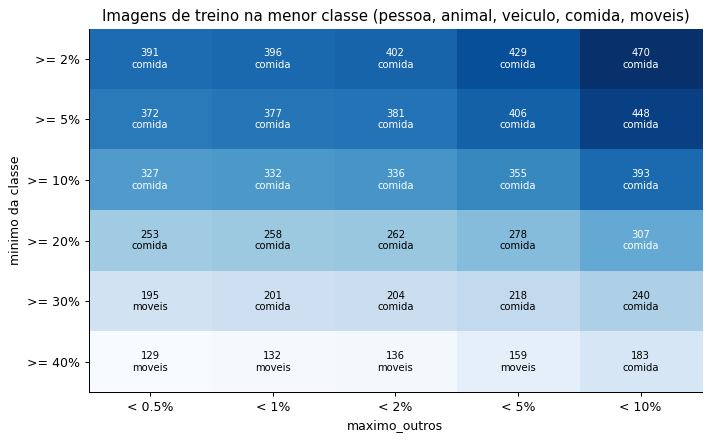

In [16]:
MINIMOS = (2, 5, 10, 20, 30, 40)
MAXIMOS = (0.5, 1, 2, 5, 10)
treino = fr.split == "treino"
menor = np.zeros((len(MINIMOS), len(MAXIMOS)), int)
qual = np.empty_like(menor, dtype=object)
for i, mi in enumerate(MINIMOS):
    for j, ma in enumerate(MAXIMOS):
        n = rotulo_exclusivo(fr, CLASSES, mi, ma)[treino].value_counts().reindex(list(CLASSES), fill_value=0)
        menor[i, j], qual[i, j] = n.min(), n.idxmin()

fig, ax = plt.subplots(figsize=(8, 5))
ax.imshow(menor, cmap="Blues", aspect="auto"); ax.grid(False)
for (i, j), n in np.ndenumerate(menor):
    ax.text(j, i, f"{n}\n{qual[i, j]}", ha="center", va="center", fontsize=8,
            color="white" if n > 0.6 * menor.max() else "black")
ax.set_xticks(range(len(MAXIMOS)), [f"< {m}%" for m in MAXIMOS])
ax.set_yticks(range(len(MINIMOS)), [f">= {m}%" for m in MINIMOS])
ax.set(xlabel="maximo_outros", ylabel="minimo da classe",
       title=f"Imagens de treino na menor classe ({', '.join(CLASSES)})")
plt.tight_layout(); plt.show()

O `minimo` pesa muito mais que o `maximo_outros`. Afrouxar a pureza de < 0,5% para < 5% ganha
poucas dezenas de imagens; subir o mínimo de 10% para 30% custa um terço da menor classe. Com 5
classes balanceadas a ≥ 10%, sobram ~330 imagens por classe.

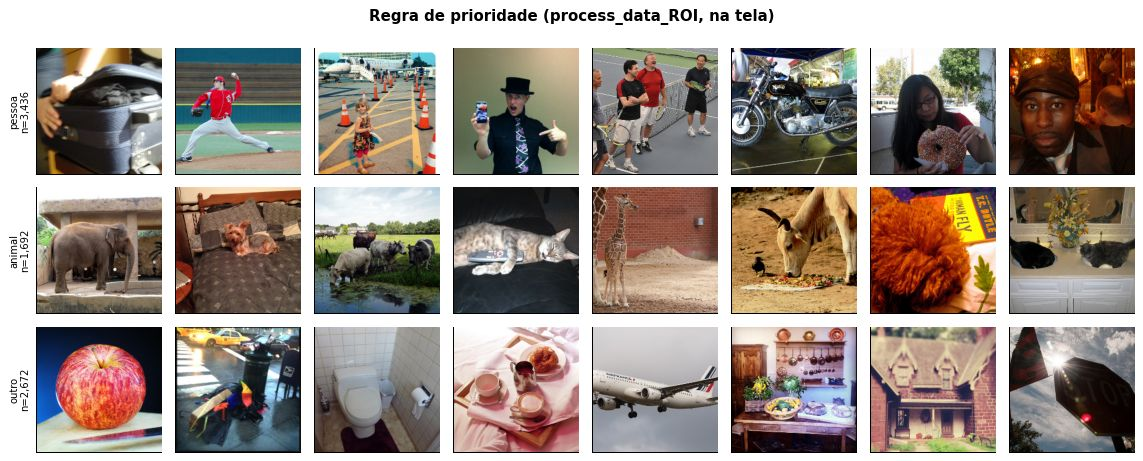

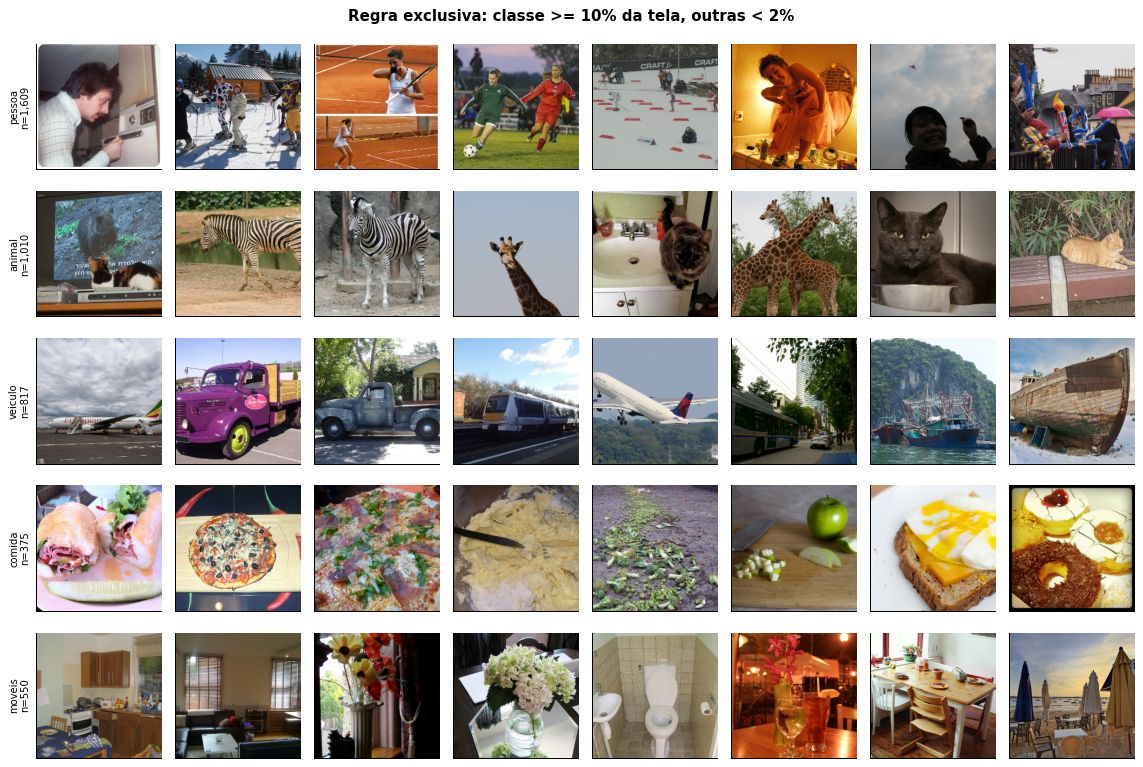

In [17]:
def galeria_classes(rot, n=8, semente=SEMENTE, titulo=""):
    rng = np.random.default_rng(semente)
    classes = [c for c in rot.dropna().unique()]
    classes = [c for c in CLASSES if c in classes] + [c for c in classes if c not in CLASSES]
    fig, axes = plt.subplots(len(classes), n, figsize=(1.6 * n, 1.75 * len(classes)))
    for i, c in enumerate(classes):
        ids = rot.index[rot == c]
        escolha = rng.choice(ids, min(n, len(ids)), replace=False)
        for j in range(n):
            ax = axes[i, j]; ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
            if j < len(escolha):
                ax.imshow(imagem(escolha[j]))
            else:
                ax.axis("off")
        axes[i, 0].set_ylabel(f"{c}\nn={len(ids):,}", fontsize=8)
    fig.suptitle(titulo, fontweight="bold")
    plt.tight_layout()
    mostra_jpeg(fig)


galeria_classes(rot_prio, titulo="Regra de prioridade (process_data_ROI, na tela)")
galeria_classes(rot_excl, titulo="Regra exclusiva: classe >= 10% da tela, outras < 2%")

## 10. O que isso dá para o treino controlado

O subconjunto semântico se combina com os outros eixos. Por classe (regra exclusiva acima): quantas
imagens únicas de treino existem com as primeiras N sessões, e quantas o teste fixo tem — o que diz
se dá para avaliar por classe.

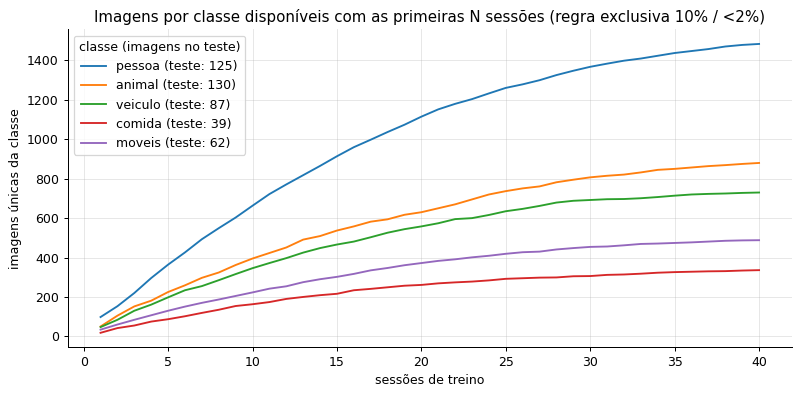

In [18]:
primeira_sessao = pd.Series(todas["sessao"]).groupby(todas["imagem"]).min()
fig, ax = plt.subplots(figsize=(9, 4.5))
sessoes = np.arange(1, 41)
for c in CLASSES:
    ids_c = rot_excl.index[(rot_excl == c) & treino]
    ps = primeira_sessao.reindex(ids_c).values
    ax.plot(sessoes, [(ps < n).sum() for n in sessoes], label=f"{c} (teste: {((rot_excl == c) & ~treino).sum()})")
ax.set(xlabel="sessões de treino", ylabel="imagens únicas da classe",
       title="Imagens por classe disponíveis com as primeiras N sessões (regra exclusiva 10% / <2%)")
ax.legend(title="classe (imagens no teste)")
plt.tight_layout(); plt.show()

As curvas crescem como o número de imagens únicas (tabela da seção 1): nenhuma classe se concentra
nas primeiras ou nas últimas sessões, então um subconjunto semântico se combina com qualquer N. No
teste, as classes têm de 39 (comida) a 130 (animal) imagens. Dá para quebrar o retrieval por
classe, mas o retrieval entre 39 candidatos é bem mais fácil que entre 1.000: a comparação entre
classes tem de usar o mesmo número de candidatos.

Para usar em outro lugar, a tabela de frações em cache já basta. Exemplo: as imagens de treino da
classe animal pela regra exclusiva, com o número de repetições de cada uma nas primeiras
`NUM_SESSOES` sessões.

In [19]:
fr_cache = pd.read_csv(CACHE, index_col="nsd_id")
rot = rotulo_exclusivo(fr_cache, CLASSES, minimo=10, maximo_outros=2)

vistas = pd.Series(todas["imagem"][no_pool]).value_counts()
animal_treino = rot.index[(rot == "animal") & rot.index.isin(ids_treino)]
print(f"{len(animal_treino)} imagens de animal no treino; repeticoes:",
      vistas.reindex(animal_treino).value_counts().sort_index().to_dict())

880 imagens de animal no treino; repeticoes: {3: 880}


## Para o treino controlado

O que este notebook deixa pronto para a configuração do dataset de treino:

| Eixo | Parâmetro | De onde sai |
|---|---|---|
| Subconjunto semântico | `classes` (listas de colunas `sup_*` / `cat_*`), `minimo`, `maximo_outros` | `rotulo_exclusivo` sobre `subj01_fracao_tela.csv` |
| Imagens únicas | quantas imagens por classe (ou no total), sorteadas com semente | as imagens rotuladas do pool de treino |
| Repetições | 1, 2 ou 3 exibições por imagem | `nsd_data.exibicoes_treino(..., 40)`: as linhas de `betas` de cada imagem |

O teste continua fixo (as 1.000 compartilhadas) e o rótulo dele serve só para quebrar as métricas
por classe. O `frr.py` já aceita qualquer subconjunto de exibições. No MindEye2, o
`train_ridgeonly.py` vai precisar filtrar as amostras do webdataset pelo índice da imagem
(`behav[:, 0, 0]`).